In [109]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [110]:
BASE_DIR = Path.cwd().parent
Data_path = BASE_DIR/'data'/'hr_churn.csv'

In [111]:
a = pd.read_csv(Data_path)
a.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [112]:
a.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [113]:
a.shape

(1470, 35)

In [139]:
a.describe()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.071062,0.161224,1.086395,0.000702,0.182710,-0.043537,-0.139116,0.600000,-0.003045,-0.270068,...,0.153741,-0.143878,-0.206122,0.142177,-0.200680,-0.238776,0.334694,0.245850,0.395918,0.224626
std,0.702721,0.367863,0.532170,0.583106,0.675572,0.512082,0.546541,0.490065,0.568655,0.711561,...,0.360824,0.540604,0.852077,0.864531,1.289271,0.706476,1.021088,0.724627,1.074143,0.713627
min,-1.384615,0.000000,0.000000,-1.011561,-0.500000,-1.000000,-1.000000,0.000000,-1.006993,-2.000000,...,0.000000,-1.000000,-1.000000,-1.111111,-3.000000,-2.000000,-0.833333,-0.600000,-0.333333,-0.600000
25%,-0.461538,0.000000,1.000000,-0.486994,-0.416667,-0.500000,-0.500000,0.000000,-0.503497,-1.000000,...,0.000000,-0.500000,-1.000000,-0.444444,-1.000000,-1.000000,-0.333333,-0.200000,-0.333333,-0.200000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.538462,0.000000,1.000000,0.513006,0.583333,0.500000,0.500000,1.000000,0.496503,0.000000,...,0.000000,0.500000,0.000000,0.555556,0.000000,0.000000,0.666667,0.800000,0.666667,0.800000
max,1.846154,1.000000,2.000000,1.007225,1.833333,1.000000,0.500000,1.000000,0.951049,1.000000,...,1.000000,0.500000,2.000000,3.333333,3.000000,1.000000,5.833333,3.000000,4.666667,2.800000


In [114]:
a.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [115]:
unique_values = pd.DataFrame({
    'Name' : [col for col in a.columns],
    'Unique_value' : [a[col].unique() for col in a.columns],
    'data_types' : [a[col].dtype for col in a.columns]
})

unique_values

,Name,Unique_value,data_types
0,Age,"[41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 2...",int64
1,Attrition,"[Yes, No]",str
2,BusinessTravel,"[Travel_Rarely, Travel_Frequently, Non-Travel]",str
3,DailyRate,"[1102, 279, 1373, 1392, 591, 1005, 1324, 1358,...",int64
4,Department,"[Sales, Research & Development, Human Resources]",str
5,DistanceFromHome,"[1, 8, 2, 3, 24, 23, 27, 16, 15, 26, 19, 21, 5...",int64
6,Education,"[2, 1, 4, 3, 5]",int64
7,EducationField,"[Life Sciences, Other, Medical, Marketing, Tec...",str
8,EmployeeCount,[1],int64
9,EmployeeNumber,"[1, 2, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16,...",int64


In [116]:
a.drop(['StandardHours','Over18','EmployeeCount','EmployeeNumber'], axis= 1, inplace = True)

In [117]:
a.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [118]:
desc_col = a.select_dtypes(include='int64').columns
for col in desc_col:
    mean = a[col].mean()
    median = a[col].median()
    if mean>median:
        print(col, ": right_skewed")
    else:
        print(col, ": left_skewed")


Age : right_skewed
DailyRate : right_skewed
DistanceFromHome : right_skewed
Education : left_skewed
EnvironmentSatisfaction : left_skewed
HourlyRate : left_skewed
JobInvolvement : left_skewed
JobLevel : right_skewed
JobSatisfaction : left_skewed
MonthlyIncome : right_skewed
MonthlyRate : right_skewed
NumCompaniesWorked : right_skewed
PercentSalaryHike : right_skewed
PerformanceRating : right_skewed
RelationshipSatisfaction : left_skewed
StockOptionLevel : left_skewed
TotalWorkingYears : right_skewed
TrainingTimesLastYear : left_skewed
WorkLifeBalance : left_skewed
YearsAtCompany : right_skewed
YearsInCurrentRole : right_skewed
YearsSinceLastPromotion : right_skewed
YearsWithCurrManager : right_skewed


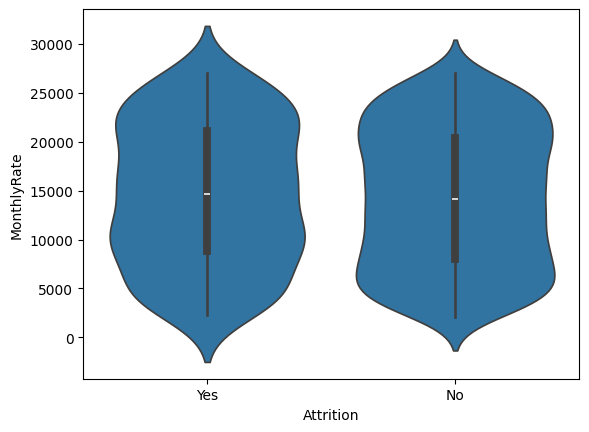

In [119]:
sns.violinplot(x='Attrition', y='MonthlyRate', data=a)
plt.show()

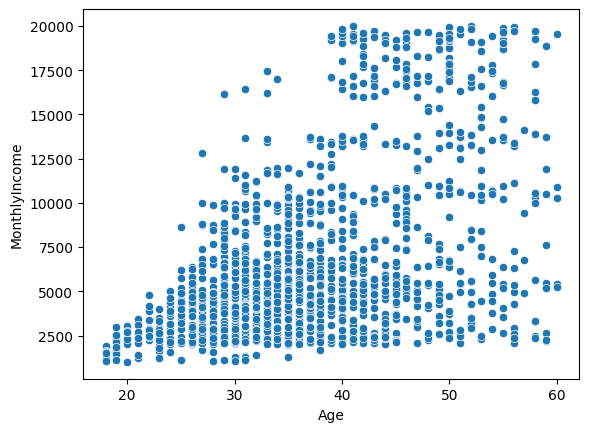

In [120]:
sns.scatterplot(data=a,x='Age',y='MonthlyIncome')
plt.show()

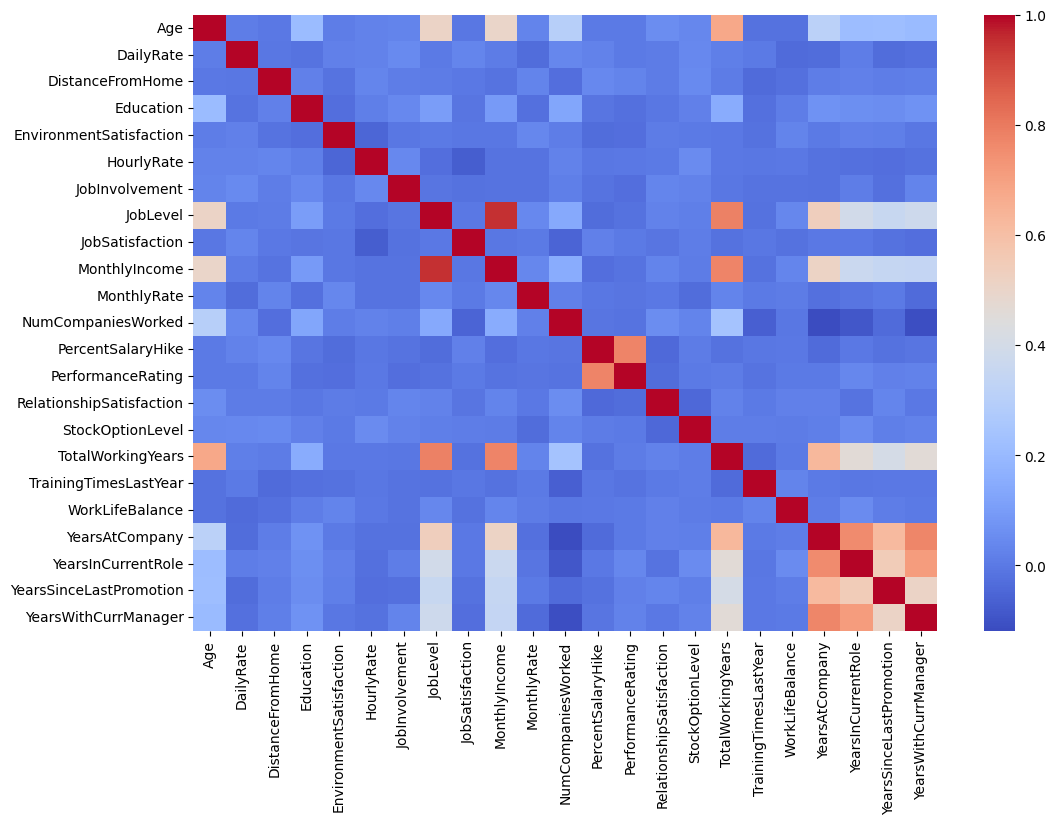

In [121]:
#Heat map
plt.figure(figsize=(12,8))
sns.heatmap(a.select_dtypes(include='number').corr(), cmap='coolwarm')
plt.show()


In [122]:
corr = a.select_dtypes(include='number').corr().abs()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant_col = [col for col in upper.columns if any(upper[col]>0.85)]
redundant_col

['MonthlyIncome']

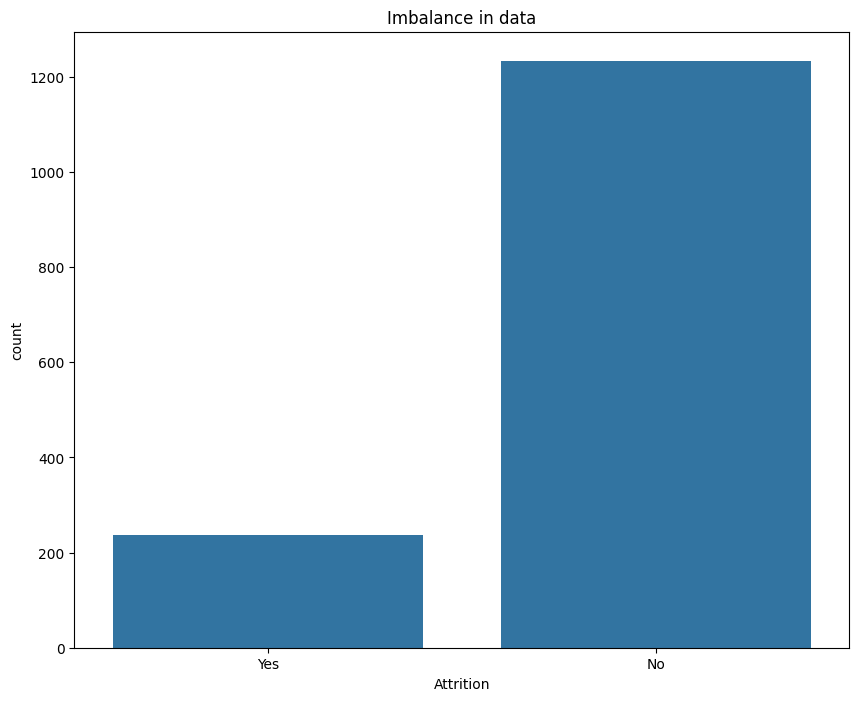

In [123]:
plt.figure(figsize=(10,8))
sns.countplot(x='Attrition', data=a)
plt.title('Imbalance in data')
plt.show()

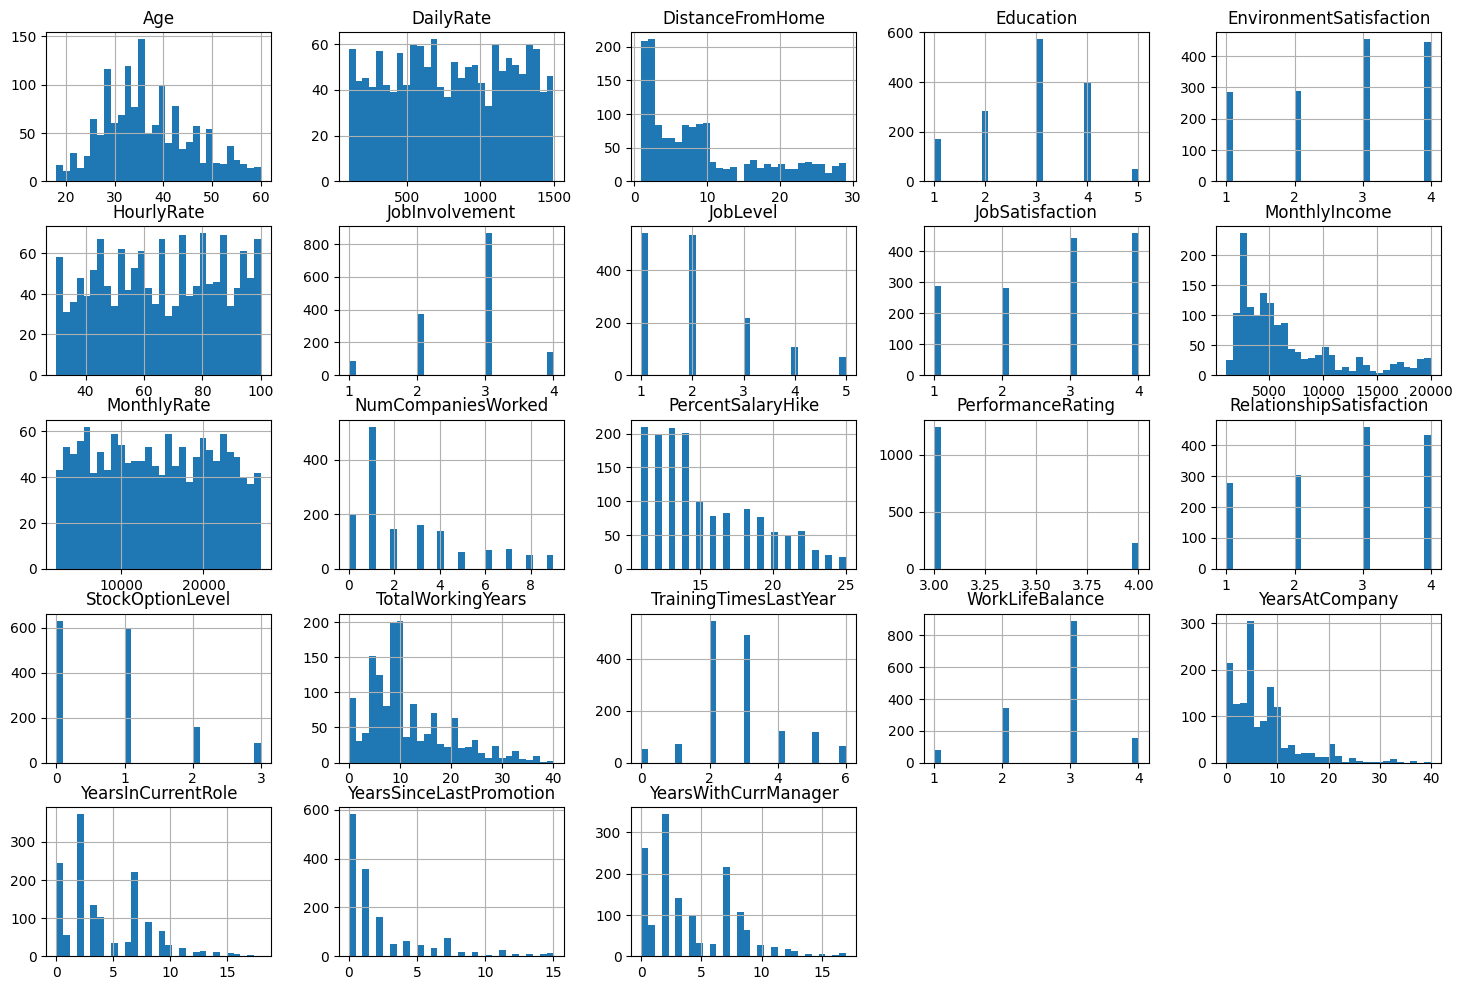

In [124]:
a.select_dtypes(include='number').hist(figsize=(18,12),  bins=30)
plt.show()

In [125]:

calculating_quan = a.loc[a['YearsWithCurrManager']< a['YearsWithCurrManager'].quantile(0.75),'YearsWithCurrManager']
calculating_quan


0       5
2       0
3       0
4       2
5       6
       ..
1462    6
1464    0
1465    3
1467    3
1469    2
Name: YearsWithCurrManager, Length: 983, dtype: int64

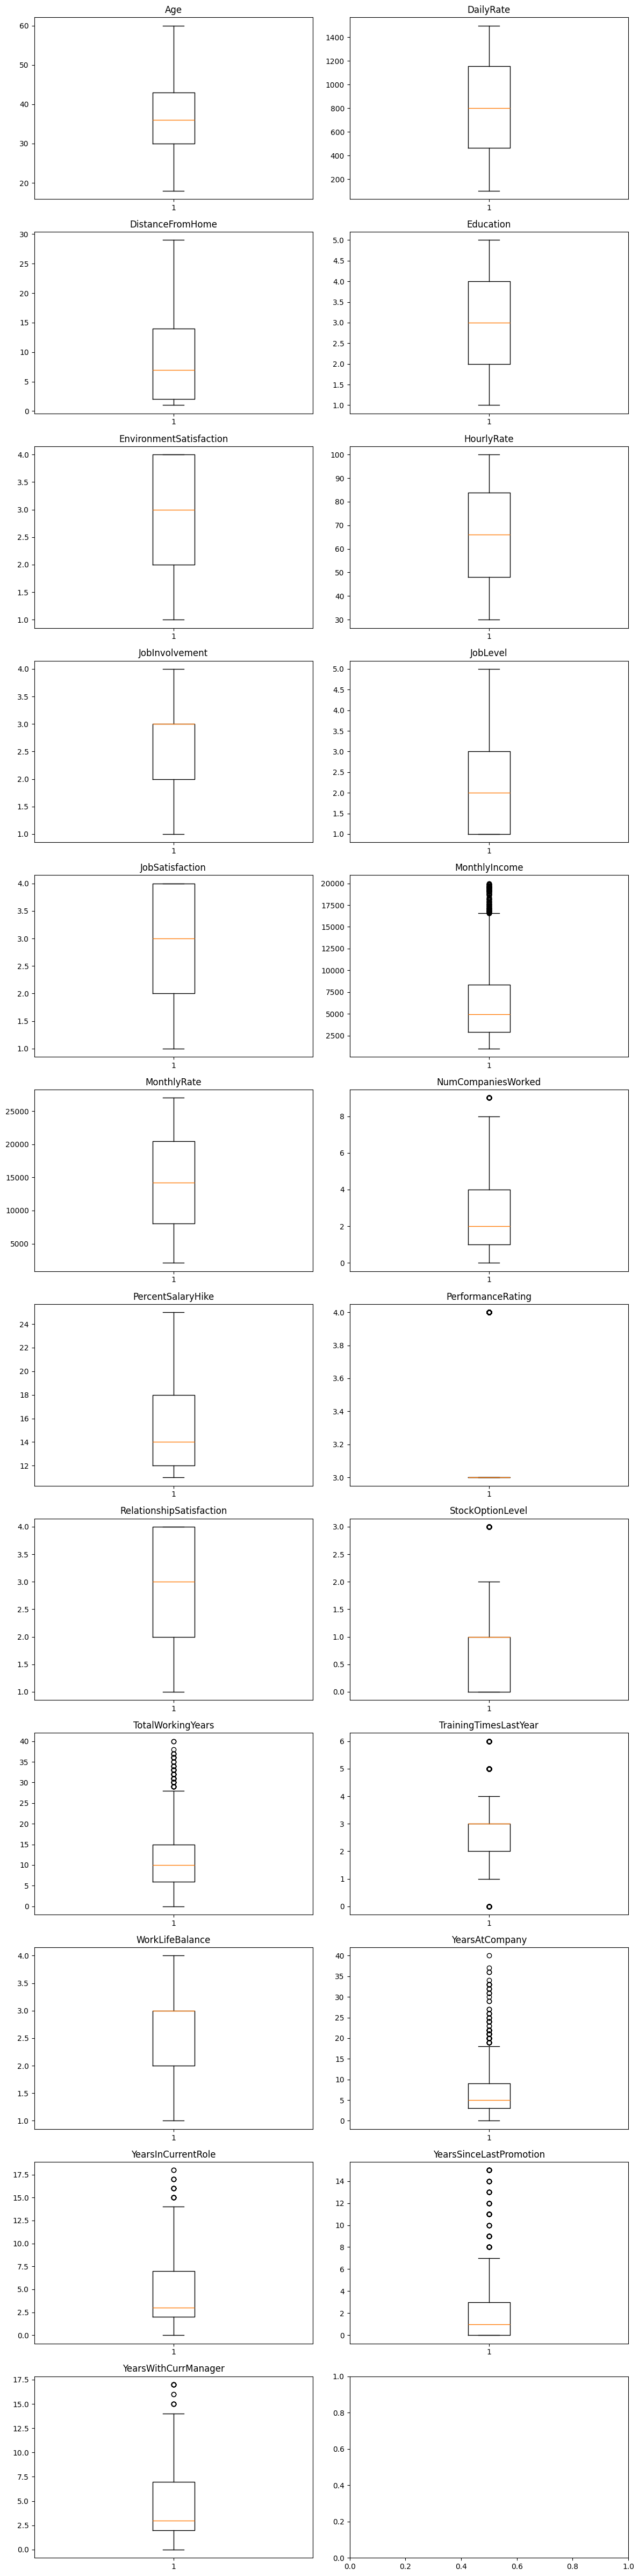

In [126]:
rows =  int(np.ceil(len(desc_col)/2))
fig, axes = plt.subplots(rows, 2, figsize=(12,4*rows))

axes = axes.flatten()

for i, col in enumerate(desc_col):
    axes[i].boxplot(a[col])
    axes[i].set_title(col)
    
plt.tight_layout()
plt.show()

In [127]:
def outlier_lims(col):
    q1 = np.percentile(col, 25)
    q3 = np.percentile(col, 75)
    IQR = q3-q1
    upper_lims = q3 + 1.5* IQR
    lower_lims = q1 - 1.5* IQR
    return upper_lims, lower_lims
    


In [128]:
for col in desc_col:
    print('---------------------------')
    print('columns - ', col)
    
    UL, LL = outlier_lims(a[col])
    print('upper limits :', UL)
    print('lower limits :', LL)
    
    outliers = a[(a[col]< LL) | (a[col]> UL)]
    percent = len(outliers)/ len(a) * 100
    
    print('Percentage of Ouliers = ', percent)
    print('-----------------------------')
    

---------------------------
columns -  Age
upper limits : 62.5
lower limits : 10.5
Percentage of Ouliers =  0.0
-----------------------------
---------------------------
columns -  DailyRate
upper limits : 2195.0
lower limits : -573.0
Percentage of Ouliers =  0.0
-----------------------------
---------------------------
columns -  DistanceFromHome
upper limits : 32.0
lower limits : -16.0
Percentage of Ouliers =  0.0
-----------------------------
---------------------------
columns -  Education
upper limits : 7.0
lower limits : -1.0
Percentage of Ouliers =  0.0
-----------------------------
---------------------------
columns -  EnvironmentSatisfaction
upper limits : 7.0
lower limits : -1.0
Percentage of Ouliers =  0.0
-----------------------------
---------------------------
columns -  HourlyRate
upper limits : 137.375
lower limits : -5.625
Percentage of Ouliers =  0.0
-----------------------------
---------------------------
columns -  JobInvolvement
upper limits : 4.5
lower limits : 

In [129]:
scaler = RobustScaler()
a[desc_col] = scaler.fit_transform(a[desc_col])

# Encoding the data

In [130]:
categorical = a.select_dtypes(include='string').columns.tolist()
categorical


['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [131]:
label_col = [ 
              col for col in a.select_dtypes(include=['string']).columns 
              if len(a[col].unique()) == 2
]
# label encoding
for col in label_col:
    vals = sorted(a[col].dropna().unique())
    a[col] = a[col].map({vals[0] :0, vals[1] :1})


In [132]:
# Ordianal encoding in short
ordinal_col = {
    'BusinessTravel' : ['Non-Travel','Travel_Rarely', 'Travel_Frequently', ]
}

ord_enc = OrdinalEncoder(categories=list(ordinal_col.values()))

a[list(ordinal_col.keys())] = ord_enc.fit_transform(a[list(ordinal_col.keys())])    

In [133]:
# OneHot Encoding
onehot_enc = [col for col in categorical if col not in label_col and col not in ordinal_col]

a = pd.get_dummies(a, columns= onehot_enc, drop_first= True)
    

In [134]:
a.head()

,Age,Attrition,BusinessTravel,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,0.384615,1,1.0,0.433526,-0.500000,-0.5,-0.5,0,0.783217,0.0,...,False,False,False,False,False,False,True,False,False,True
1,1.000000,0,2.0,-0.755780,0.083333,-1.0,0.0,1,-0.139860,-1.0,...,False,False,False,False,False,True,False,False,True,False
2,0.076923,1,1.0,0.825145,-0.416667,-0.5,0.5,1,0.727273,-1.0,...,False,True,False,False,False,False,False,False,False,True
3,-0.230769,0,2.0,0.852601,-0.333333,0.5,0.5,0,-0.279720,0.0,...,False,False,False,False,False,True,False,False,True,False
4,-0.692308,0,1.0,-0.304913,-0.416667,-1.0,-1.0,1,-0.727273,0.0,...,False,True,False,False,False,False,False,False,True,False


# Train and Testing Data

In [135]:
x = a.drop('Attrition',axis=1)
y = a['Attrition']

In [136]:
model = LogisticRegression(class_weight='balanced')
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.75      0.82       255
           1       0.26      0.59      0.36        39

    accuracy                           0.72       294
   macro avg       0.59      0.67      0.59       294
weighted avg       0.83      0.72      0.76       294



In [137]:
model  = RandomForestClassifier(class_weight='balanced')
x_train,x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       1.00      0.10      0.19        39

    accuracy                           0.88       294
   macro avg       0.94      0.55      0.56       294
weighted avg       0.90      0.88      0.84       294

